# Lab: Vision Transformers & Graph Neural Networks

---

**Objective:** Build hands-on understanding of two powerful architectures - the **Vision Transformer (ViT)** for image classification and **Graph Neural Networks (GNNs)** for learning on graph-structured data - by implementing core components and running lightweight experiments.

<!-- | Section | What you'll learn |
|---|---|
| **Part 1** | How ViT converts images into patch sequences |
| **Part 2** | Patch embedding, positional encoding, and the [CLS] token |
| **Part 3** | End-to-end ViT on CIFAR-10 (small-scale demo) |
| **Part 4** | Graphs, adjacency matrices, and why CNNs fail on them |
| **Part 5** | Message passing - the core idea behind GNNs |
| **Part 6** | Building a GCN from scratch in NumPy |
| **Part 7** | GCN for node classification on Cora (with PyTorch Geometric) |
| **Part 8** | Exercises & further reading | -->

## Part 0 : Setup

In [1]:
!pip install torch-geometric -q

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.7 MB/s eta 0:00:00
Using device: cuda


---
## Part 1 : Turning Images into Sequences

### 1.1 The Core Insight

Standard Transformers operate on **sequences of tokens**. For NLP, these are words or sub-words. The key innovation of the **Vision Transformer** (Dosovitskiy et al., ICLR 2021) is treating an image as a sequence of **patches**:

1. Split the image into a grid of fixed-size patches (e.g., 16×16 pixels)
2. Flatten each patch into a vector
3. Linearly project it to the model's embedding dimension
4. Prepend a learnable **[CLS] token** and add **positional embeddings**
5. Feed the resulting sequence into a standard Transformer encoder

The Transformer encoder output at the [CLS] position is then used for classification via an MLP head.

### 1.2 Visualising the Patching Process

Let's see how a 32×32 image (CIFAR-10 size) gets split into patches.

100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s]


Image shape: torch.Size([3, 32, 32]) (C, H, W)
Label: airplane


/tmp/ipykernel_442/74506937.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


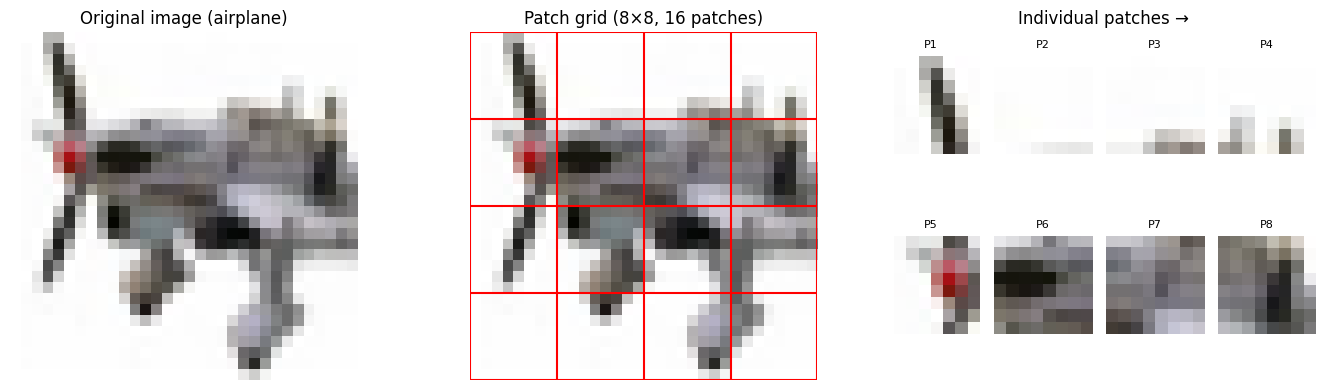


Each patch: 8×8×3 = 192 values
Sequence length for Transformer: 16 patches + 1 [CLS] token = 17


In [2]:
from torchvision import datasets, transforms

# Load a single CIFAR-10 image for demonstration
transform = transforms.Compose([transforms.ToTensor()])
cifar10 = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
img, label = cifar10[49]  # Pick an example
class_names = cifar10.classes

print(f"Image shape: {img.shape} (C, H, W)")
print(f"Label: {class_names[label]}")

# Show the original image
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img.permute(1, 2, 0).numpy())
axes[0].set_title(f"Original image ({class_names[label]})")
axes[0].axis('off')

# Show patch grid overlay
PATCH_SIZE = 8  # 32/8 = 4 patches per side = 16 patches total
axes[1].imshow(img.permute(1, 2, 0).numpy())
for i in range(0, 33, PATCH_SIZE):
    axes[1].axhline(i - 0.5, color='red', linewidth=1.5)
    axes[1].axvline(i - 0.5, color='red', linewidth=1.5)
axes[1].set_title(f"Patch grid ({PATCH_SIZE}×{PATCH_SIZE}, {(32//PATCH_SIZE)**2} patches)")
axes[1].axis('off')

# Extract and show individual patches
n_patches_side = 32 // PATCH_SIZE
patches = img.unfold(1, PATCH_SIZE, PATCH_SIZE).unfold(2, PATCH_SIZE, PATCH_SIZE)
patches = patches.contiguous().view(3, -1, PATCH_SIZE, PATCH_SIZE).permute(1, 2, 3, 0)

# Show first 8 patches in a row
for i in range(min(8, patches.shape[0])):
    ax_inset = fig.add_axes([0.67 + (i % 4) * 0.08, 0.55 - (i // 4) * 0.45, 0.07, 0.35])
    ax_inset.imshow(patches[i].numpy())
    ax_inset.set_title(f"P{i+1}", fontsize=8)
    ax_inset.axis('off')

axes[2].axis('off')
axes[2].set_title("Individual patches →")
plt.tight_layout()
plt.show()

print(f"\nEach patch: {PATCH_SIZE}×{PATCH_SIZE}×3 = {PATCH_SIZE*PATCH_SIZE*3} values")
print(f"Sequence length for Transformer: {n_patches_side**2} patches + 1 [CLS] token = {n_patches_side**2 + 1}")

**Key takeaway:** The image is reshaped from a 2D grid into a 1D sequence of patch vectors - exactly the format a Transformer expects. The patch size controls the trade-off between sequence length and the amount of spatial detail each token encodes.

---
## Part 2 : Patch Embedding, [CLS] Token, and Positional Encoding

### 2.1 Patch Embedding

Each flattened patch (of size $P^2 \cdot C$) is projected to a $D$-dimensional vector via a learnable linear layer. This is equivalent to applying a convolution with kernel size = stride = patch size.

$$\mathbf{z}_i = W_E \cdot \text{flatten}(\text{patch}_i) + b_E, \quad W_E \in \mathbb{R}^{D \times P^2C}$$

### 2.2 The [CLS] Token

A special learnable embedding $\mathbf{x}_{\text{class}}$ is prepended to the sequence. After passing through the Transformer encoder, this token's output captures **global image information** (by attending to all patches), and is used as the representation for classification.

### 2.3 Positional Encoding

 We add **learnable positional embeddings** $E_{\text{pos}}$ so the model knows where each patch came from spatially:

$$Z = [\mathbf{x}_{\text{class}}; \; \mathbf{z}_1; \; \mathbf{z}_2; \; \ldots; \; \mathbf{z}_N] + E_{\text{pos}}$$

Unlike the original Transformer which uses fixed sinusoidal encodings, ViT uses **learned** positional embeddings.

### 2.4 Implementation

In [3]:
class PatchEmbedding(nn.Module):
    """Split image into patches and project to embedding dimension."""

    def __init__(self, img_size=32, patch_size=8, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2

        # Conv2d with kernel_size=stride=patch_size is equivalent to
        # extracting patches and linearly projecting them
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x: (B, C, H, W) -> (B, embed_dim, H/P, W/P) -> (B, N, embed_dim)
        x = self.projection(x)       # (B, D, grid_h, grid_w)
        x = x.flatten(2).transpose(1, 2)  # (B, N, D)
        return x


# Demo
embed_dim = 128
patch_embed = PatchEmbedding(img_size=32, patch_size=8, embed_dim=embed_dim)
sample_img = img.unsqueeze(0)  # Add batch dimension

patch_tokens = patch_embed(sample_img)
print(f"Input image shape:  {sample_img.shape}")
print(f"Patch tokens shape: {patch_tokens.shape}  (batch, n_patches, embed_dim)")
print(f"\nThe image is now a sequence of {patch_tokens.shape[1]} vectors, each of dimension {embed_dim}")

Input image shape:  torch.Size([1, 3, 32, 32])
Patch tokens shape: torch.Size([1, 16, 128])  (batch, n_patches, embed_dim)

The image is now a sequence of 16 vectors, each of dimension 128


[CLS] token shape: torch.Size([1, 1, 128])
After prepending [CLS]: torch.Size([1, 17, 128])  (16 patches + 1 [CLS] = 17 tokens)
After adding positional embeddings: torch.Size([1, 17, 128])


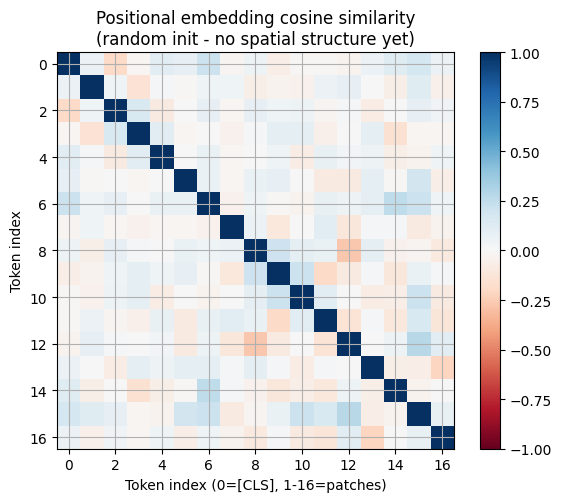

After training, nearby patches will develop similar positional embeddings,
revealing that the model learns a 2D spatial structure from 1D positions.


In [4]:
# Demonstrate adding [CLS] token and positional embeddings
n_patches = patch_tokens.shape[1]

# Learnable [CLS] token
cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
print(f"[CLS] token shape: {cls_token.shape}")

# Prepend [CLS] to patch tokens
cls_expanded = cls_token.expand(1, -1, -1)  # match batch size
tokens = torch.cat([cls_expanded, patch_tokens], dim=1)
print(f"After prepending [CLS]: {tokens.shape}  ({n_patches} patches + 1 [CLS] = {n_patches + 1} tokens)")

# Learnable positional embeddings
pos_embed = nn.Parameter(torch.randn(1, n_patches + 1, embed_dim))
tokens_with_pos = tokens + pos_embed
print(f"After adding positional embeddings: {tokens_with_pos.shape}")

# Visualise the positional embedding similarity matrix
# If the model learns spatial structure, nearby patches should have similar embeddings
pe = pos_embed.detach().squeeze(0).numpy()
similarity = pe @ pe.T
norm = np.linalg.norm(pe, axis=1, keepdims=True)
cos_sim = (pe @ pe.T) / (norm @ norm.T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cos_sim, cmap='RdBu', vmin=-1, vmax=1)
ax.set_title("Positional embedding cosine similarity\n(random init - no spatial structure yet)")
ax.set_xlabel("Token index (0=[CLS], 1-16=patches)")
ax.set_ylabel("Token index")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("After training, nearby patches will develop similar positional embeddings,")
print("revealing that the model learns a 2D spatial structure from 1D positions.")

---
## Part 3 : End-to-End ViT on CIFAR-10

Now let's put it all together and train a small ViT on CIFAR-10. Given CIFAR-10's tiny 32×32 images and limited compute, we use a deliberately compact architecture.

### 3.1 The Complete ViT Model

In [5]:
class ViT(nn.Module):
    """
    Vision Transformer for image classification.
    Compact version suitable for CIFAR-10 (32x32 images).
    """

    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 num_classes=10, embed_dim=128, depth=4,
                 num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches

        # Learnable [CLS] token and positional embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches + 1, embed_dim) * 0.02)
        self.pos_drop = nn.Dropout(dropout)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-norm (more stable training)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

        # Classification head (MLP on [CLS] token output)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]

        # 1. Patch embedding
        x = self.patch_embed(x)                           # (B, N, D)

        # 2. Prepend [CLS] token
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)                    # (B, N+1, D)

        # 3. Add positional embeddings
        x = self.pos_drop(x + self.pos_embed)

        # 4. Transformer encoder
        x = self.transformer(x)                            # (B, N+1, D)
        x = self.norm(x)

        # 5. Classification head on [CLS] token
        cls_output = x[:, 0]                               # (B, D)
        return self.head(cls_output)                       # (B, num_classes)


model = ViT(
    img_size=32, patch_size=8, in_channels=3, num_classes=10,
    embed_dim=128, depth=4, num_heads=4, mlp_ratio=2.0, dropout=0.1
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ViT parameters: {n_params:,}")

# Quick shape check
dummy = torch.randn(2, 3, 32, 32).to(device)
out = model(dummy)
print(f"Input: {dummy.shape} -> Output: {out.shape}")

/tmp/ipykernel_442/3116543885.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


ViT parameters: 574,986
Input: torch.Size([2, 3, 32, 32]) -> Output: torch.Size([2, 10])


### 3.2 Data Loading and Training

In [7]:
# Data augmentation helps a lot for ViT on small datasets
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# Use a subset for fast demonstration
train_set = datasets.CIFAR10('./data', train=True, download=True, transform=train_transform)
test_set  = datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)



In [9]:
EPOCHS = 10
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

train_losses, test_accs = [], []

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Evaluate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = 100 * correct / total
    test_accs.append(acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Loss: {avg_loss:.4f} | Test Acc: {acc:.1f}%")

print(f"\nFinal test accuracy: {test_accs[-1]:.1f}%")

Epoch   1 | Train Loss: 1.4482 | Test Acc: 48.6%
Epoch   5 | Train Loss: 1.2806 | Test Acc: 55.2%
Epoch  10 | Train Loss: 1.1673 | Test Acc: 58.3%

Final test accuracy: 58.3%


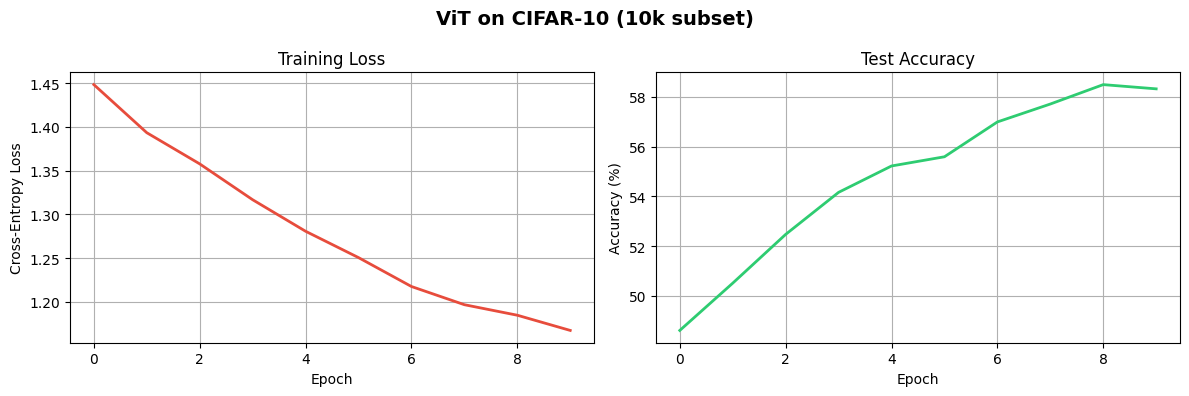

Note: Full CIFAR-10 (50k) with longer training and larger models reaches ~85%+.
ViT truly shines on larger datasets (ImageNet) where it matches or beats CNNs.


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, linewidth=2, color='#e74c3c')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss')

ax2.plot(test_accs, linewidth=2, color='#2ecc71')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy')

fig.suptitle('ViT on CIFAR-10 (10k subset)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("Note: Full CIFAR-10 (50k) with longer training and larger models reaches ~85%+.")
print("ViT truly shines on larger datasets (ImageNet) where it matches or beats CNNs.")

---
## Part 4 : Graphs and Why CNNs Fail on Them

### 4.1 What is a Graph?

A graph $G = (V, E)$ consists of **nodes** (vertices) $V$ and **edges** $E$ connecting them. Graphs naturally represent social networks, molecules, citation networks, road systems, and many other relational structures.

Key representations:
- **Adjacency matrix** $A \in \{0,1\}^{n \times n}$: $A_{ij} = 1$ if there's an edge from node $i$ to $j$
- **Node feature matrix** $X \in \mathbb{R}^{n \times f}$: each node has $f$ features

### 4.2 Why CNNs Can't Handle Graphs

CNNs rely on **fixed grid structure** - every pixel has the same number of neighbors arranged in a regular spatial layout. This allows sliding a fixed-size kernel across the image.

Graphs break this assumption:
- Nodes have **variable numbers** of neighbors
- There is **no fixed spatial layout** or notion of "left" and "right"
- **Node ordering is arbitrary** - relabelling nodes changes the adjacency matrix but not the graph

Let's visualise this concretely.

In [ ]:
import networkx as nx

# Create a small example graph
G = nx.karate_club_graph()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: A simple graph
small_G = nx.Graph()
small_G.add_edges_from([(0,1),(0,2),(1,2),(1,3),(2,3),(2,4),(3,5),(4,5)])
pos = nx.spring_layout(small_G, seed=42)
nx.draw(small_G, pos, ax=axes[0], with_labels=True, node_color='#3498db',
        node_size=500, font_size=12, font_weight='bold', edge_color='gray', width=2)
axes[0].set_title("A simple graph\n(no grid structure!)")

# Plot 2: Its adjacency matrix
A = nx.adjacency_matrix(small_G).todense()
axes[1].imshow(A, cmap='Blues')
for i in range(len(A)):
    for j in range(len(A)):
        axes[1].text(j, i, int(A[i,j]), ha='center', va='center', fontsize=11)
axes[1].set_title("Adjacency matrix A")
axes[1].set_xlabel("Node"); axes[1].set_ylabel("Node")

# Plot 3: Variable neighbor count
degrees = [small_G.degree(n) for n in small_G.nodes()]
axes[2].bar(range(len(degrees)), degrees, color='#e74c3c', alpha=0.8)
axes[2].set_xlabel("Node"); axes[2].set_ylabel("Number of neighbors")
axes[2].set_title("Variable neighborhood size\n(CNN kernels can't handle this)")
axes[2].set_xticks(range(len(degrees)))

plt.tight_layout(); plt.show()

print("A CNN kernel of fixed size (e.g. 3×3) assumes exactly 8 neighbors.")
print(f"But in this graph, nodes have between {min(degrees)} and {max(degrees)} neighbors.")
print("GNNs solve this by aggregating over variable-size neighborhoods.")

---
## Part 5 : Message Passing - The Core GNN Idea

### 5.1 The Framework

Graph Neural Networks learn node representations by iteratively **aggregating information from neighbors**. At each layer $k$, every node $v$ updates its representation:

$$h_v^{(k+1)} = \text{UPDATE}\!\left(h_v^{(k)},\; \text{AGGREGATE}\big(\{h_u^{(k)} : u \in N(v)\}\big)\right)$$

where $N(v)$ is the set of neighbors of node $v$, and $h_v^{(0)} = x_v$ (the input features).

This is called **message passing**: each node "sends messages" to its neighbors, which aggregate and update their states.

### 5.2 Let's Do a detailed dive in the formulation
Most modern GNNs follow the **Message Passing Neural Network (MPNN)** framework.

For each node $v$, the update happens in two stages.

#### Step 1: Message Aggregation

A node collects information from its neighbors.

$$
m_v^{(k)} = AGG^{(k)} \left( \{ h_u^{(k)} : u \in N(v) \} \right)
$$

**Where:**

- $h_u^{(k)}$ = embedding of neighbor $u$ at layer $k$  
- $N(v)$ = neighbors of node $v$  
- $AGG$ = aggregation function (sum, mean, max etc..)

#### Step 2: Node Update

The node updates its embedding using the aggregated message.

$$
h_v^{(k+1)} = \sigma \left( W^{(k)} \cdot [\, h_v^{(k)} \, || \, m_v^{(k)} \,] \right)
$$

**Where:**

- $||$ = concatenation  
- $W^{(k)}$ = trainable weight matrix  
- $\sigma$ = activation function (ReLU, etc.)

### 5.3 Why This Works

After $K$ layers, each node's embedding incorporates information from all nodes within $K$ hops. The aggregation functions (sum, mean, max) are **permutation-invariant**, meaning the output doesn't depend on the order of neighbors - exactly what we need for graphs.

### 5.4 Visualising the Computation Graph

In [ ]:
# Visualise the computation graph for node A
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original graph
G_demo = nx.Graph()
edges = [('A','B'), ('A','C'), ('A','D'), ('B','C'), ('C','E'), ('C','F'), ('E','F')]
G_demo.add_edges_from(edges)
pos = {'A': (0,0), 'B': (1,1), 'C': (1,-0.5), 'D': (-1, -0.5), 'E': (2,-1), 'F': (2,0.5)}

colors = ['#e74c3c' if n == 'A' else '#3498db' for n in G_demo.nodes()]
nx.draw(G_demo, pos, ax=axes[0], with_labels=True, node_color=colors,
        node_size=700, font_size=14, font_weight='bold', edge_color='gray', width=2)
axes[0].set_title("Input graph\n(target node A in red)", fontsize=13)

# Computation tree for node A (2 layers)
tree = nx.DiGraph()
# Layer 2 (root)
tree.add_node("A (L2)")
# Layer 1
for n in ['B (L1)', 'C (L1)', 'D (L1)']:
    tree.add_edge(n, "A (L2)")
# Layer 0 - neighbors of B, C, D
tree.add_edge("A (L0)", "B (L1)")
tree.add_edge("C (L0)", "B (L1)")
tree.add_edge("A (L0')", "C (L1)")
tree.add_edge("B (L0)", "C (L1)")
tree.add_edge("E (L0)", "C (L1)")
tree.add_edge("F (L0)", "C (L1)")
tree.add_edge("A (L0'')", "D (L1)")

tree_pos = {
    "A (L2)": (3, 2),
    "B (L1)": (1, 1), "C (L1)": (3, 1), "D (L1)": (5, 1),
    "A (L0)": (0, 0), "C (L0)": (1.2, 0),
    "A (L0')": (2, 0), "B (L0)": (2.8, 0), "E (L0)": (3.6, 0), "F (L0)": (4.2, 0),
    "A (L0'')": (5, 0),
}

tree_colors = ['#e74c3c' if 'A (L2)' in n else '#f39c12' if 'L1' in n else '#2ecc71'
               for n in tree.nodes()]
nx.draw(tree, tree_pos, ax=axes[1], with_labels=True, node_color=tree_colors,
        node_size=600, font_size=8, font_weight='bold', edge_color='gray',
        width=1.5, arrows=True, arrowsize=15)
axes[1].set_title("Computation graph for node A\n(2 layers deep)", fontsize=13)

# Add layer labels
axes[1].text(-0.5, 0, "Layer 0\n(input features)", fontsize=10, ha='center', color='#2ecc71')
axes[1].text(-0.5, 1, "Layer 1\n(1-hop agg.)", fontsize=10, ha='center', color='#f39c12')
axes[1].text(-0.5, 2, "Layer 2\n(2-hop agg.)", fontsize=10, ha='center', color='#e74c3c')

plt.tight_layout(); plt.show()

print("After 2 layers, node A's embedding encodes information from its 2-hop neighborhood.")
print("The same aggregation function and weights are shared across ALL nodes (weight sharing).")

---
## Part 6 : Graph Convolutional Network From Scratch

### 6.1 The GCN Layer (Kipf & Welling, 2017)

The most common GNN variant is the **Graph Convolutional Network**. Its forward pass for layer $k$:

$$H^{(k+1)} = \sigma\!\left(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2} H^{(k)} W^{(k)}\right)$$

where:
- $\hat{A} = A + I$ is the adjacency matrix with added self-loops
- $\hat{D}$ is the degree matrix of $\hat{A}$
- $W^{(k)}$ is a learnable weight matrix
- $\sigma$ is a non-linearity (e.g., ReLU)

In simpler terms: **average your neighbors' features (including yourself), then apply a linear transform and activation.** The normalisation by $\hat{D}^{-1/2}$ prevents nodes with many neighbors from dominating.

### 6.2 Deep Dive into Formulation
#### Dimensions of the Matrices

First understand the shapes.

Let:

- $N$ = number of nodes  
- $F_l$ = feature dimension at layer $l$  
- $F_{l+1}$ = feature dimension at the next layer  

Then:

$$
H^{(l)} \in \mathbb{R}^{N \times F_l}
$$

$$
W^{(l)} \in \mathbb{R}^{F_l \times F_{l+1}}
$$

##### Multiplication

$$
H^{(l)} W^{(l)} \in \mathbb{R}^{N \times F_{l+1}}
$$

So each node's feature vector is linearly transformed to a new feature space.

#### Node-wise Interpretation

Each row of $H^{(l)}$ is a node embedding.

For node $v$:

$$
h_v^{(l)} \in \mathbb{R}^{F_l}
$$

When multiplied by $W^{(l)}$:

$$
h_v^{(l)} W^{(l)} = z_v^{(l)}
$$

where

$$
z_v^{(l)} \in \mathbb{R}^{F_{l+1}}
$$

This is exactly the same as a **linear layer in a standard neural network**.

##### Expanded form

$$
z_v^{(l)} = W^{(l)T} h_v^{(l)}
$$

##### Component-wise form

$$
z_{v,i}^{(l)} =
\sum_{j=1}^{F_l}
W_{j,i}^{(l)} \, h_{v,j}^{(l)}
$$

So each new feature is a **weighted combination of old features**.

### 6.3
## 1. What Happens if We Just Multiply by $A$?

Suppose we use a simple formulation:

$$
H^{(l+1)} = A H^{(l)} W^{(l)}
$$

Matrix multiplication $AH$ means:

$$
h_v^{(l+1)} =
\sum_{u \in N(v)} h_u^{(l)}
$$

So each node **sums the features of its neighbors**.

### Problem

Nodes with many neighbors will have much larger values.

Example:

- Node A → 2 neighbors  
- Node B → 100 neighbors  

Then:

$$
h_B = \sum_{i=1}^{100} h_i
$$

which is **50× larger than A’s representation**.

So node embeddings become biased by **node degree**, not **feature content**.

---

# 2. First Fix: Divide by Degree

A simple fix is to **average neighbor features**:

$$
h_v^{(l+1)} =
\frac{1}{d_v}
\sum_{u \in N(v)} h_u^{(l)}
$$

Matrix form:

$$
D^{-1} A H
$$

This gives:

- average of neighbor features  
- equal scaling across nodes

Now every node receives **equal-scale information regardless of degree**.

---

# 3. Why GCN Uses Symmetric Normalization

Instead of

$$
D^{-1}A
$$

GCN uses

$$
D^{-1/2} A D^{-1/2}
$$

This gives the update:

$$
h_v^{(l+1)} =
\sum_{u \in N(v)}
\frac{1}{\sqrt{d_v d_u}}
h_u^{(l)}
$$

So the contribution of neighbor $u$ becomes:

$$
\frac{1}{\sqrt{d_v d_u}}
$$
### Reason 1 - Balanced Influence Between Nodes

If node $u$ has very high degree, its influence should be smaller.

Without normalization:

High-degree nodes dominate the graph.

With normalization:

Their influence is down-weighted.

---

### Reason 2 - Numerical Stability

Repeated graph propagation can cause feature explosion.

Example:

Without normalization:

Layer 1 -> neighbors summed  
Layer 2 -> neighbors of neighbors summed  

Values grow rapidly.

Normalization keeps values bounded.

---

### Reason 3 - Spectral Graph Theory

GCN originates from **spectral graph convolution** using the graph Laplacian.

Normalized Laplacian:

$$
L = I - D^{-1/2} A D^{-1/2}
$$

Using this normalization preserves important **spectral properties of the graph** and ensures stable convolution.

---


## 6. Role of Self-Loops

GCN actually uses:

$$
\hat{A} = A + I
$$

So the final propagation matrix becomes:

$$
\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}
$$

Self-loops ensure that a node also keeps its own information:

$$
h_v^{(l+1)} =
\frac{1}{\sqrt{d_v d_v}} h_v +
\sum_{u \in N(v)}
\frac{1}{\sqrt{d_v d_u}} h_u
$$

Meaning:

A node also retains **its own features** while aggregating information from its neighbors.

### 6.4 NumPy Implementation

In [ ]:
def gcn_layer_numpy(A, H, W):
    """
    One GCN layer in pure NumPy.

    Args:
        A: adjacency matrix (n, n) - no self-loops yet
        H: node features (n, d_in)
        W: weight matrix (d_in, d_out)
    Returns:
        H_new: updated features (n, d_out)
    """
    n = A.shape[0]

    # Step 1: Add self-loops → A_hat = A + I
    A_hat = A + np.eye(n)

    # Step 2: Compute degree matrix D_hat
    D_hat = np.diag(A_hat.sum(axis=1))

    # Step 3: Symmetric normalisation D^{-1/2} A_hat D^{-1/2}
    D_inv_sqrt = np.diag(1.0 / np.sqrt(A_hat.sum(axis=1)))
    A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

    # Step 4: Aggregate → transform → activate
    H_new = A_norm @ H @ W  # Neighbourhood aggregation + linear transform
    H_new = np.maximum(0, H_new)  # ReLU activation

    return H_new


# Demo on our small graph
A_small = np.array(nx.adjacency_matrix(small_G).todense(), dtype=float)
n_nodes = A_small.shape[0]

# Random node features (6 nodes, 4 features each)
X = np.random.randn(n_nodes, 4)

# Two GCN layers: 4 → 8 → 2
W1 = np.random.randn(4, 8) * 0.5
W2 = np.random.randn(8, 2) * 0.5

H1 = gcn_layer_numpy(A_small, X, W1)
H2 = gcn_layer_numpy(A_small, H1, W2)

print("Input features X (6 nodes × 4 features):")
print(np.round(X, 3))
print(f"\nAfter GCN layer 1: {H1.shape}")
print(f"After GCN layer 2: {H2.shape} (2D embeddings for visualisation)")

# Visualise the learned 2D embeddings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Graph with node colors
node_labels = {i: str(i) for i in range(n_nodes)}
pos_small = nx.spring_layout(small_G, seed=42)
nx.draw(small_G, pos_small, ax=ax1, with_labels=True, node_color=H2[:, 0],
        cmap='coolwarm', node_size=600, font_size=12, font_weight='bold', width=2)
ax1.set_title("Graph (colored by embedding dim 0)")

# 2D embedding space
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
for i in range(n_nodes):
    ax2.scatter(H2[i, 0], H2[i, 1], c=colors[i], s=200, zorder=5, edgecolors='black')
    ax2.annotate(str(i), (H2[i, 0], H2[i, 1]), fontsize=12, fontweight='bold',
                 ha='center', va='center')
ax2.set_xlabel("Embedding dim 0"); ax2.set_ylabel("Embedding dim 1")
ax2.set_title("2D node embeddings after 2 GCN layers\n(connected nodes should be closer)")

plt.tight_layout(); plt.show()

print("\nNotice how connected nodes tend to end up closer in the embedding space.")
print("This is because each GCN layer mixes information between neighbors.")

---
## Part 7 : Node Classification on Cora with PyTorch Geometric

### 7.1 The Cora Dataset

Cora is a **citation network** of 2,708 research papers (nodes). Each paper is connected to papers it cites (edges), and is described by a 1,433-dimensional bag-of-words feature vector. The task is to classify each paper into one of 7 research topics.

This is a **node classification** task - exactly what GNNs are designed for.

### 7.2 Loading and Exploring the Data

Processing...


Dataset: Cora()
Number of nodes: 2708
Number of edges: 10556
Node feature dimension: 1433
Number of classes: 7

Train / Val / Test split:
  Train nodes: 140
  Val nodes:   500
  Test nodes:  1000


Done!


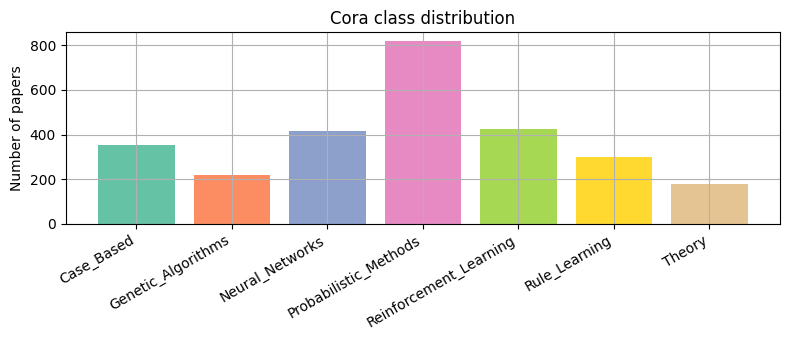

In [11]:
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# Load Cora
dataset = Planetoid(root='./data', name='Cora')
data = dataset[0]

print(f"Dataset: {dataset}")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Node feature dimension: {data.num_node_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"\nTrain / Val / Test split:")
print(f"  Train nodes: {data.train_mask.sum().item()}")
print(f"  Val nodes:   {data.val_mask.sum().item()}")
print(f"  Test nodes:  {data.test_mask.sum().item()}")

# Class distribution
class_names = ['Case_Based', 'Genetic_Algorithms', 'Neural_Networks',
               'Probabilistic_Methods', 'Reinforcement_Learning', 'Rule_Learning', 'Theory']
class_counts = [(data.y == i).sum().item() for i in range(7)]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(class_names, class_counts, color=plt.cm.Set2.colors[:7])
ax.set_ylabel("Number of papers"); ax.set_title("Cora class distribution")
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

### 7.3 Building the GCN

In [12]:
class GCN(nn.Module):
    """GCN with variable number of layers for node classification."""
    def __init__(self, n_features, n_hidden, n_classes, n_layers, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.n_layers = n_layers

        self.convs = nn.ModuleList()

        # First layer: input → hidden
        self.convs.append(GCNConv(n_features, n_hidden))

        # Intermediate layers: hidden → hidden
        for _ in range(n_layers - 2):
            self.convs.append(GCNConv(n_hidden, n_hidden))

        # Final layer: hidden → classes
        if n_layers >= 1:
            self.convs.append(GCNConv(n_hidden, n_classes))
        # (for n_layers=1 the single layer already goes → n_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)

            # Apply activation + dropout to all layers except the last
            if i < self.n_layers - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)

        return x




In [14]:
depths = [2, 3, 4, 6, 8, 10, 16]
best_test_accs = []

for depth in depths:
    model_gcn = GCN(
        n_features = dataset.num_features,
        n_hidden   = 64,
        n_classes  = dataset.num_classes,
        n_layers   = depth,
        dropout    = 0.5
    )

    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)

    best_val_acc = 0.0
    best_test_acc = 0.0

    print(f"\nTraining GCN with {depth} layers...")

    for epoch in range(1, 201):
        # === Train ===
        model_gcn.train()
        optimizer.zero_grad()
        logits = model_gcn(data)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # === Validation + Test (under no_grad) ===
        model_gcn.eval()
        with torch.no_grad():
            logits = model_gcn(data)

            # Validation
            val_pred = logits[data.val_mask].argmax(dim=1)
            val_acc = (val_pred == data.y[data.val_mask]).float().mean().item() * 100

            # Test (only for monitoring — not used for selection)
            test_pred = logits[data.test_mask].argmax(dim=1)
            test_acc = (test_pred == data.y[data.test_mask]).float().mean().item() * 100

            # Save best model according to validation performance
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc  # this is the key: test of the best val model

        if epoch % 40 == 0 or epoch == 1 or epoch == 200:
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | "
                  f"Val: {val_acc:.2f}% | Test: {test_acc:.2f}%  "
                  f"(best test so far: {best_test_acc:.2f}%)")

    best_test_accs.append(best_test_acc)
    print(f"→ Depth {depth:2d} → Best test accuracy (by val): {best_test_acc:.2f}%")


Training GCN with 2 layers...
Epoch   1 | Loss: 1.9517 | Val: 11.20% | Test: 9.90%  (best test so far: 9.90%)
Epoch  40 | Loss: 1.9404 | Val: 11.20% | Test: 9.90%  (best test so far: 9.90%)
Epoch  80 | Loss: 1.9517 | Val: 11.20% | Test: 9.90%  (best test so far: 9.90%)
Epoch 120 | Loss: 1.9512 | Val: 11.20% | Test: 9.90%  (best test so far: 9.90%)
Epoch 160 | Loss: 1.9460 | Val: 11.20% | Test: 9.90%  (best test so far: 9.90%)
Epoch 200 | Loss: 1.9516 | Val: 11.20% | Test: 9.90%  (best test so far: 9.90%)
→ Depth  2 → Best test accuracy (by val): 9.90%

Training GCN with 3 layers...
Epoch   1 | Loss: 1.9432 | Val: 22.20% | Test: 23.70%  (best test so far: 23.70%)
Epoch  40 | Loss: 1.9495 | Val: 22.20% | Test: 23.70%  (best test so far: 23.70%)
Epoch  80 | Loss: 1.9434 | Val: 22.20% | Test: 23.70%  (best test so far: 23.70%)
Epoch 120 | Loss: 1.9437 | Val: 22.20% | Test: 23.70%  (best test so far: 23.70%)
Epoch 160 | Loss: 1.9462 | Val: 22.20% | Test: 23.70%  (best test so far: 23.70%)


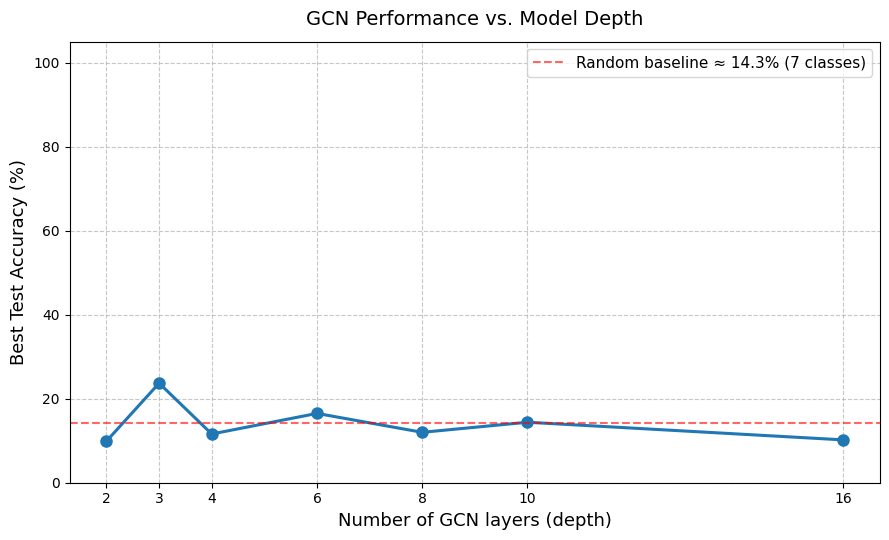

→ Accuracy **peaks** at depth = 3
   → Best test accuracy = 23.7%

→ Accuracy drops **below random baseline** (14.3%) at depth = 2
   (and stays below for deeper models)

Depth vs Accuracy:
   2      9.9% ↓ below random
   3     23.7% ★
   4     11.6% ↓ below random
   6     16.5%
   8     12.0% ↓ below random
  10     14.4%
  16     10.2% ↓ below random


In [16]:

best_test_accs_pct = [acc * 100 if acc <= 1.0 else acc for acc in best_test_accs]

# ───── Plot ───────────────────────────────────────
plt.figure(figsize=(9, 5.5))
plt.plot(depths, best_test_accs_pct, marker='o', color='#1f77b4', linewidth=2.2, markersize=8)
plt.xlabel('Number of GCN layers (depth)', fontsize=13)
plt.ylabel('Best Test Accuracy (%)', fontsize=13)
plt.title('GCN Performance vs. Model Depth', fontsize=14, pad=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Mark random baseline
plt.axhline(y=100/7, color='red', linestyle='--', alpha=0.6,
            label=f'Random baseline ≈ {100/7:.1f}% (7 classes)')
plt.legend(fontsize=11)

plt.legend(fontsize=11)

plt.xticks(depths)
plt.ylim(0, max(105, max(best_test_accs_pct) + 5))
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(best_test_accs_pct)]
best_acc = max(best_test_accs_pct)
print(f"→ Accuracy **peaks** at depth = {best_depth}")
print(f"   → Best test accuracy = {best_acc:.1f}%\n")

# When it drops below random (~14.2857%)
random_baseline = 100 / 7

below_random_depths = [d for d, acc in zip(depths, best_test_accs_pct)
                       if acc < random_baseline]

if below_random_depths:
    first_below = below_random_depths[0]
    print(f"→ Accuracy drops **below random baseline** ({random_baseline:.1f}%) "
          f"at depth = {first_below}")
    print(f"   (and stays below for deeper models)")

print("\nDepth vs Accuracy:")
for d, acc in zip(depths, best_test_accs_pct):
    marker = " ★" if d == best_depth else ""
    below = " ↓ below random" if acc < random_baseline else ""
    print(f"  {d:2d}    {acc:5.1f}%{marker}{below}")

### 7.4 Training and Evaluation

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, linewidth=2, color='#e74c3c')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss')

ax2.plot(val_accs, linewidth=2, color='#3498db', label='Validation')
ax2.plot(test_accs_gcn, linewidth=2, color='#2ecc71', label='Test')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Node Classification Accuracy')
ax2.legend()

fig.suptitle('GCN on Cora Citation Network', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"The GCN achieves ~{max(test_accs_gcn):.0f}% accuracy with just 2 layers and ~92K parameters.")
print("A simple MLP (ignoring graph structure) typically gets only ~55-60% on this task.")

### 7.5 Visualising Learned Node Embeddings

Let's extract the embeddings from the GCN's hidden layer and project them to 2D with t-SNE.

In [ ]:
from sklearn.manifold import TSNE

# Extract hidden representations (after conv1, before conv2)
model_gcn.eval()
with torch.no_grad():
    x = data.x
    x = model_gcn.conv1(x, data.edge_index)
    x = F.relu(x)
    embeddings = x.cpu().numpy()

labels = data.y.cpu().numpy()

# t-SNE projection
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                     c=labels, cmap='Set1', s=10, alpha=0.7)
legend = ax.legend(*scatter.legend_elements(), title="Class", loc='upper right', fontsize=8)
ax.set_title("t-SNE of GCN hidden embeddings (Cora)\nPapers of the same topic cluster together")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
plt.tight_layout(); plt.show()

print("The GCN has learned to map papers of the same research area to nearby regions,")
print("using BOTH the paper's own features AND the citation structure.")

---
## Part 8 : Exercises & Further Reading

### Exercises

**ViT:**
1. Increase the training subset to the full 50k CIFAR-10. How much does accuracy improve? Plot the training loss and test accuracy curves .
Hint : Minimal change in section 3.2

**GNN:**
2. **Accuracy vs Layers.**
   Modify the `GCN` class above so that it accepts an `n_layers` parameter and builds a variable number of `GCNConv` layers using an `nn.ModuleList`. The first layer should map `n_features -> n_hidden`, intermediate layers `n_hidden -> n_hidden`, and the final layer `n_hidden -> n_classes`. Then:

   - Train a GCN for each depth in `[2, 3, 4, 6, 8, 10, 16]`, recording the best test accuracy for each.
   - Plot depth (x-axis) vs. best test accuracy (y-axis).
   - At what depth does accuracy peak? When does it drop below a random baseline (~14% for 7 classes)?
   - Relate your findings to the diameter: once the number of layers approaches the diameter, every node's embedding mixes information from nearly the entire graph. Why would that hurt classification?

   Find out what this phenomenon is called
   
    Optional : Can plot TSNE embeddings for small number of layers like 2 and large number of layers like 16
    
### Further Reading

| Topic | Resource |
|---|---|
| **ViT** | [An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929) - Dosovitskiy et al., ICLR 2021 |
| **DeiT** | [Training Data-Efficient Image Transformers](https://arxiv.org/abs/2012.12877) - Touvron et al. (ViT for smaller datasets) |
| **GCN** | [Semi-Supervised Classification with GCNs](https://arxiv.org/abs/1609.02907) - Kipf & Welling, ICLR 2017 |
| **GraphSAGE** | [Inductive Representation Learning on Large Graphs](https://arxiv.org/abs/1706.02216) - Hamilton et al. |
| **GAT** | [Graph Attention Networks](https://arxiv.org/abs/1710.10903) - Veličković et al. (attention on graphs) |
| **PyG Tutorials** | [pytorch-geometric.readthedocs.io](https://pytorch-geometric.readthedocs.io/en/latest/) |
| **Stanford CS224W** | [Graph Machine Learning course](http://web.stanford.edu/class/cs224w/) - comprehensive GNN course |

## **Please solve the exercises post this cell, take code from demo , make appropriate changes and execute them post this markdown cell**

In [5]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.3 MB/s eta 0:00:00


In [6]:
import torch
import numpy as np
from torch_geometric.data import Data
from torchvision import datasets, transforms

transform = transforms.ToTensor()
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

def img_to_grid_graph(img):
    img = img.squeeze()                     # ensure [28,28]
    if img.dim() != 2:
        raise ValueError(f"Expected 2D image, got shape {img.shape}")

    intensity = img.view(-1, 1).float()     # [784, 1]

    i, j = torch.meshgrid(
        torch.arange(28, device=img.device),
        torch.arange(28, device=img.device),
        indexing='ij'
    )
    pos = torch.stack([i.flatten(), j.flatten()], dim=1).float() / 27.0  # [784, 2]

    x = torch.cat([intensity, pos], dim=1)  # [784, 3]

    # edges (your existing code)
    edges = []
    for y in range(28):
        for x_ in range(28):   # renamed to avoid conflict with variable x
            idx = y * 28 + x_
            if x_ < 27:
                edges.extend([[idx, idx+1], [idx+1, idx]])
            if y < 27:
                edges.extend([[idx, idx+28], [idx+28, idx]])
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index, orig_img=img)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.43MB/s]


In [7]:
from torch_geometric.nn import GCNConv
class DiffusingGCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(3, 16)
        self.conv2 = GCNConv(16, 8)
        self.conv3 = GCNConv(8, 1)   # back toward scalar activation

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)
        return x.sigmoid()   # [784,1] ≈ smoothed "importance"

In [8]:
model = DiffusingGCN()           # can be random / untrained — diffusion still happens
# or train it briefly for reconstruction / denoising if you want better quality

collected = []  # list of (px, py, value)

for k, (img, label) in enumerate(mnist):
    if label not in [0,6,8,9]: continue          # round digits only
    if img.mean() < 0.07: continue               # skip almost empty

    graph = img_to_grid_graph(img)
    print("graph:", graph)
    print("graph.x type:", type(graph.x), "shape:", graph.x.shape if isinstance(graph.x, torch.Tensor) else "NOT A TENSOR")
    print("graph.x[:5]:", graph.x[:5] if isinstance(graph.x, torch.Tensor) else graph.x)
    with torch.no_grad():
       score = model(graph).squeeze()           # [784]

    orig = graph.orig_img.flatten()              # [784]

    mask = (score > 0.15) & (orig > 0.12)

    flat_idx = torch.where(mask)[0]              # only one tensor → indices
    if len(flat_idx) == 0:
       continue                                 # skip empty images

    ys = flat_idx // 28
    xs = flat_idx %  28
    vals = orig[flat_idx]

# Optional: small drift
    dx = (score[flat_idx] - 0.5) * 1.2
    dy = (score[flat_idx] - 0.5) * 1.2

    for x, y, v, ddx, ddy in zip(xs, ys, vals, dx, dy):
        collected.append((x.item() + ddx.item(), y.item() + ddy.item(), v.item()))

    if len(collected) > 35000: break   # enough points

print(f"Collected {len(collected)} real pixels after GCN guidance")

graph: Data(x=[784, 3], edge_index=[2, 3024], orig_img=[28, 28])
graph.x type: <class 'torch.Tensor'> shape: torch.Size([784, 3])
graph.x[:5]: tensor([[0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0370],
        [0.0000, 0.0000, 0.0741],
        [0.0000, 0.0000, 0.1111],
        [0.0000, 0.0000, 0.1481]])
graph: Data(x=[784, 3], edge_index=[2, 3024], orig_img=[28, 28])
graph.x type: <class 'torch.Tensor'> shape: torch.Size([784, 3])
graph.x[:5]: tensor([[0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0370],
        [0.0000, 0.0000, 0.0741],
        [0.0000, 0.0000, 0.1111],
        [0.0000, 0.0000, 0.1481]])
graph: Data(x=[784, 3], edge_index=[2, 3024], orig_img=[28, 28])
graph.x type: <class 'torch.Tensor'> shape: torch.Size([784, 3])
graph.x[:5]: tensor([[0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0370],
        [0.0000, 0.0000, 0.0741],
        [0.0000, 0.0000, 0.1111],
        [0.0000, 0.0000, 0.1481]])
graph: Data(x=[784, 3], edge_index=[2, 3024], orig_img=[28

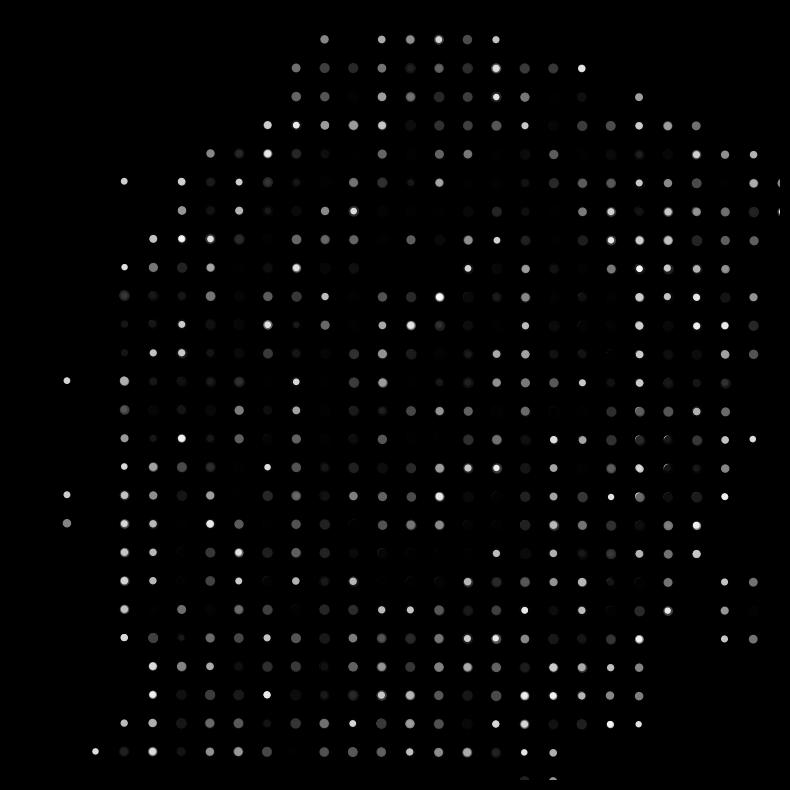

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,10), facecolor='black')
ax = fig.add_subplot(111)

# Very rough parametric smiley (scale ≈ 0–27)
t = np.linspace(0, 2*np.pi, 600)

head   = 12 * np.array([np.cos(t), np.sin(t)]).T + [14,14]
eye_l  =  3 * np.array([np.cos(t), np.sin(t)]).T + [9, 18]
eye_r  =  3 * np.array([np.cos(t), np.sin(t)]).T + [19,18]

smile_t = np.linspace(0.2*np.pi, 0.8*np.pi, 350)
smile  = 7.5 * np.array([np.cos(smile_t + np.pi), np.sin(smile_t + np.pi)]).T + [14, 8]

mask_points = np.vstack([head, eye_l, eye_r, smile])

# Scatter only pixels roughly inside the smiley region (or density modulate)
pxs, pys, vs = np.array(collected).T

# Simple distance-to-closest-smiley-point filter (or use better mask)
dists = np.min(np.linalg.norm(np.stack([pxs,pys],axis=1)[:,None,:] - mask_points[None,:,:], axis=2), axis=1)
keep = dists < 6.5   # tune this radius

ax.scatter(pxs[keep], 27-pys[keep],   # flip y for matplotlib
           s=15 + vs[keep]*45,
           c=vs[keep], cmap='gray_r', alpha=0.9, edgecolor='none')

ax.set_xlim(0,27)
ax.set_ylim(0,27)
ax.set_aspect('equal')
ax.axis('off')
plt.show()